# Hospital Readmission Prediction: Modelling & Evaluation

**Objective:** Train a Random Forest classifier on the 3 clinical dimensions, evaluate performance with cross-validation and a held-out test set, and interpret results through feature importance, ROC curve and confusion matrix.

**Input:** `features.csv` (produced by `02_feature_engineering.ipynb`)
**Stack:** Python, pandas, scikit-learn, matplotlib, seaborn

---

**Steps covered in this notebook:**
1. Machine Learning: Random Forest + Baseline
2. Model Evaluation & Explainability
3. Conclusion & Discussion


# Imports & Load Features

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")

# --- Safe paths (IMPORTANT) ---
PLOT_DIR = "../Plot"
os.makedirs(PLOT_DIR, exist_ok=True)

# --- Load dataset ---
df = pd.read_csv("../data/features.csv")

print(f"Features loaded: {df.shape[0]:,} encounters")
print(f"Columns: {list(df.columns)}")

# --- sanity check ---
print("\nTarget distribution:")
print(df['is_readmitted'].value_counts(normalize=True).round(3))

# --- Split features / target ---
X = df.drop(columns=['is_readmitted', 'split', 'patient_nbr'])
y = df['is_readmitted']

print("\nDataset shape:")
print("X:", X.shape)
print("y:", y.shape)

Features loaded: 101,766 encounters
Columns: ['dim_terrain', 'dim_instability', 'dim_severity', 'is_readmitted', 'split', 'patient_nbr']

Target distribution:
is_readmitted
0    0.539
1    0.461
Name: proportion, dtype: float64

Dataset shape:
X: (101766, 3)
y: (101766,)


# 8. Machine Learning: Random Forest + Baseline

## 8.1 Reconstruct Train / Test Split

The `split` column exported in `02_feature_engineering.ipynb` encodes whether each row belongs to the training or test set. Filtering on it recovers the exact same split used during feature construction, with no random resampling. The split was made by patient (`patient_nbr`), so no patient appears in both sets.


In [2]:
print("="*50)
print("TRAIN TEST / SPLIT RECONSTRUCTION")
print("="*50)

features = ['dim_terrain', 'dim_instability', 'dim_severity']

train_df = df[df['split'] == 'train'].copy()
test_df  = df[df['split'] == 'test'].copy()

X_train = train_df[features]
y_train = train_df['is_readmitted']

X_test = test_df[features]
y_test = test_df['is_readmitted']

print("Dataset split reconstruction:")
print(f"  Training set : {X_train.shape[0]:,} encounters")
print(f"  Test set     : {X_test.shape[0]:,} encounters")

print("\nClass distribution (% readmitted):")
print(f"  Train : {y_train.mean()*100:.1f}%")
print(f"  Test  : {y_test.mean()*100:.1f}%")

assert len(X_train) + len(X_test) == len(df), "Split error!"
print("Split integrity check passed")

TRAIN TEST / SPLIT RECONSTRUCTION
Dataset split reconstruction:
  Training set : 81,613 patients
  Test set     : 20,153 patients

Class distribution (% readmitted):
  Train : 46.3%
  Test  : 45.3%
Split integrity check passed


**Results:** the reconstructed split matches the one used during feature engineering: 81,613 training encounters and 20,153 test encounters, at readmission rates of 46.3% and 45.3%. The split integrity check confirms no mismatch between the two notebooks.


## 8.2 Baseline + Random Forest

In clinical prediction tasks, model performance is always interpreted relative to a baseline. A naive model (random prediction) defines a performance floor; any useful model must significantly outperform it to be considered clinically relevant.

5-fold cross-validation (folds grouped by patient) is used on the training set for robust performance estimation, with the test set reserved for final unbiased assessment only.

**Random Forest configuration:**
- `class_weight='balanced'` to handle class imbalance without resampling
- `n_estimators=100` for stable ensemble performance
- `max_depth=10` to reduce overfitting and improve generalisation
- Final evaluation on a held-out test set, never used during training

This design prioritises generalisation over training performance, which matters in healthcare applications where overfitting can lead to unsafe predictions.


In [3]:
# --- Baseline (DummyClassifier) ---
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)
dummy_proba = dummy.predict_proba(X_test)[:, 1]
dummy_auc = roc_auc_score(y_test, dummy_proba)

# --- Random Forest ---
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Cross-validation on train set
# Grouped by patient: folds never share a patient
cv_scores = cross_val_score(model, X_train, y_train, cv=GroupKFold(n_splits=5),
                            groups=train_df['patient_nbr'], scoring='roc_auc')
print(f"CV AUC (train): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Final fit on full train set
model.fit(X_train, y_train)
y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)

# --- Summary ---
print("\nModel summary:")
print(f"  Baseline AUC  : {dummy_auc:.3f}")
print(f"  Model AUC     : {roc_auc:.3f}")
print(f"  Absolute gain : {roc_auc - dummy_auc:.3f}")
print(f"  Relative gain : {(roc_auc / dummy_auc):.2f}x")

CV AUC (train): 0.648 ± 0.002



Model summary:
  Baseline AUC  : 0.500
  Model AUC     : 0.649
  Absolute gain : 0.149
  Relative gain : 1.30x


**Results:** the Random Forest reaches a cross-validated training AUC of 0.648 ± 0.002, and 0.649 on the held-out test set, essentially matching the CV estimate (no overfitting to the training folds). Against the baseline AUC of 0.500, this is an absolute gain of +0.149 and a relative gain of 1.30x.


# 9. Model Evaluation & Explainability

A ROC-AUC score alone isn't sufficient for clinical deployment. Three complementary visualisations support interpretation:
- **Confusion matrix**: clinical prediction reliability (sensitivity, specificity, missed cases)
- **ROC curve**: discrimination ability relative to the naive benchmark
- **Feature importance**: what the model actually learned from the three clinical dimensions

## 9.1 Evaluation Dashboard


MODEL EVALUATION DASHBOARD
Sensitivity (Recall)     : 0.512
Specificity              : 0.711
False Negatives (missed): 4,459
False Positives (alerts): 3,187


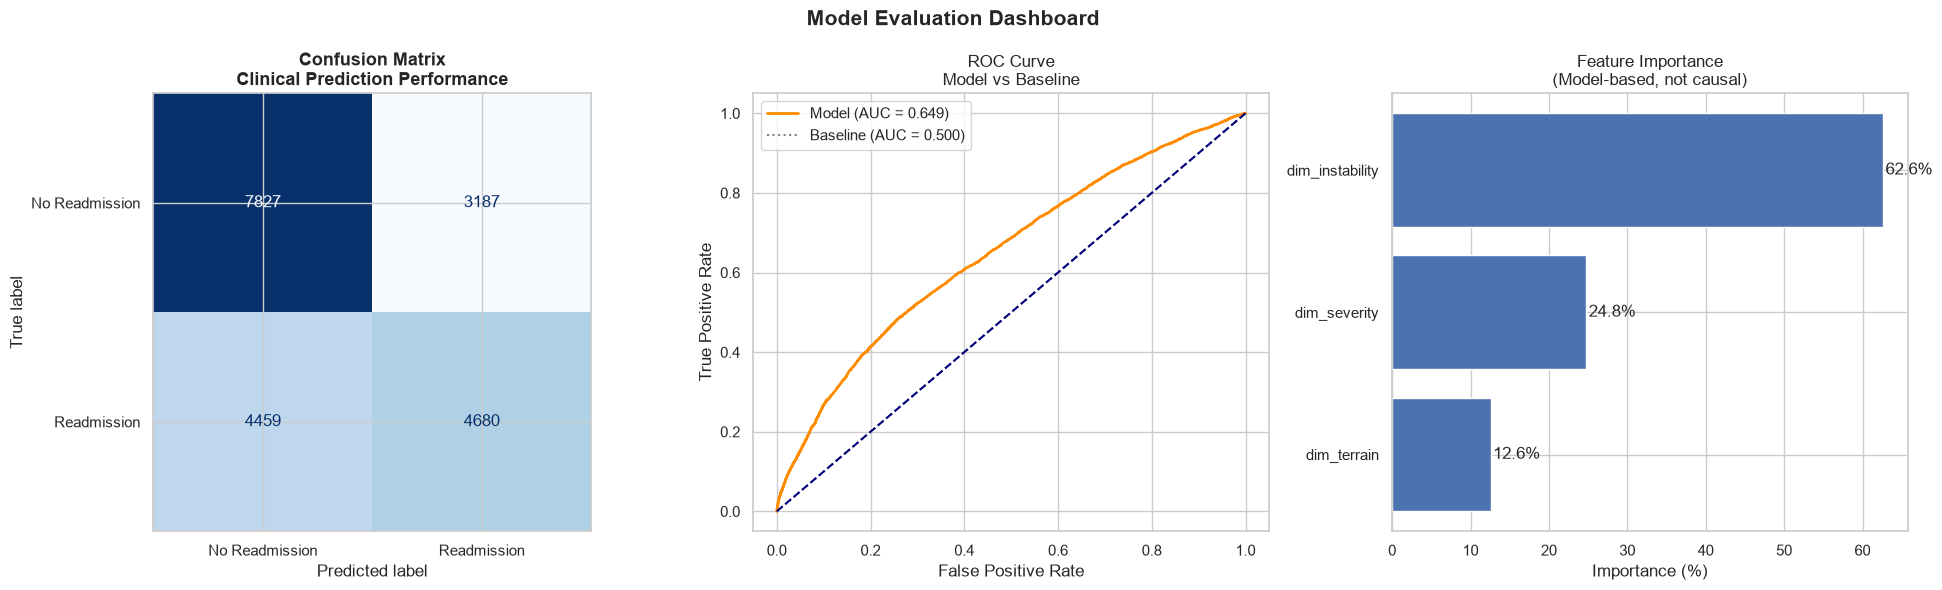

In [4]:
print("="*50)
print("MODEL EVALUATION DASHBOARD")
print("="*50)

y_pred = model.predict(X_test)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Readmission', 'Readmission']
)

disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(
    'Confusion Matrix\nClinical Prediction Performance',
    fontsize=13, fontweight='bold'
)

tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity (Recall)     : {sensitivity:.3f}")
print(f"Specificity              : {specificity:.3f}")
print(f"False Negatives (missed): {fn:,}")
print(f"False Positives (alerts): {fp:,}")

# --- Plot 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_proba)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'Model (AUC = {roc_auc:.3f})')

axes[1].plot(fpr_dummy, tpr_dummy, color='gray', lw=1.5, linestyle=':',
             label=f'Baseline (AUC = {dummy_auc:.3f})')

axes[1].plot([0, 1], [0, 1], linestyle='--', color='navy')

axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve\nModel vs Baseline')
axes[1].legend()

# --- Plot 3: Feature Importance ---
importances = model.feature_importances_

df_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances * 100
}).sort_values('Importance')

axes[2].barh(df_imp['Feature'], df_imp['Importance'])

axes[2].set_xlabel('Importance (%)')
axes[2].set_title('Feature Importance\n(Model-based, not causal)')

for i, v in enumerate(df_imp['Importance']):
    axes[2].text(v + 0.3, i, f'{v:.1f}%', va='center')

plt.suptitle('Model Evaluation Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(
    os.path.join(PLOT_DIR, "model_evaluation_dashboard.png"),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**Results:** at the default classification threshold, the model reaches a sensitivity (recall) of 0.512 and a specificity of 0.711. In absolute terms, it misses 4,459 readmitted patients (false negatives) while flagging 3,187 patients who won't be readmitted (false positives). The feature importance plot confirms Chronic Instability as the dominant predictor, consistent with its stronger correlation with the target seen in the previous notebook.


In [5]:
# --- Save trained model ---
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)
joblib.dump(model, os.path.join(MODEL_DIR, "readmission_model.pkl"))
print(f"Model saved → {MODEL_DIR}\/readmission_model.pkl")

Model saved → ../models\/readmission_model.pkl


<>:5: SyntaxWarning: invalid escape sequence '\/'
<>:5: SyntaxWarning: invalid escape sequence '\/'
C:\Users\Juliette Vanessa\AppData\Local\Temp\ipykernel_10948\1757727709.py:5: SyntaxWarning: invalid escape sequence '\/'
  print(f"Model saved → {MODEL_DIR}\/readmission_model.pkl")


> **Export result.** The fitted Random Forest is saved to `models/readmission_model.pkl`. Reusing it requires the feature-construction parameters from `models/feature_params.pkl`; the model must therefore be deployed together with the preprocessing artefact and the exact three-feature contract.


# 10. Conclusion & Discussion

## 10.1 Key Findings

Hospital readmission (any delay after discharge) in diabetic patients can be predicted with moderate performance (ROC-AUC ≈ 0.649 on the held-out test set) using only three clinically interpretable composite dimensions derived from administrative data, clearly outperforming a non-informative baseline (AUC = 0.500), a relative gain of 1.30x.

**Chronic Instability** (prior hospital and emergency admissions) emerges as the strongest predictor, consistent with established clinical evidence linking prior healthcare utilisation to increased readmission risk. At the operating threshold used, the model reaches a sensitivity (recall) of 0.512 and a specificity of 0.711: it correctly flags about half of patients who will be readmitted, missing 4,459 of them (false negatives) while raising 3,187 false alerts on patients who won't be readmitted (false positives). This sensitivity/specificity balance is typical for a screening tool built from a small number of administrative variables, and could be shifted toward higher sensitivity (at the cost of more false alerts) depending on the clinical use case.

## 10.2 Methodological Insights

- **Expert-driven dimensionality reduction** preferred over PCA to preserve clinical meaning
- **Strict train/test discipline**: all preprocessing performed on the training set only, no data leakage
- **MinMax scaling** guarantees comparability across dimensions
- **Correlation-based weighting** used as a pragmatic signal-strength heuristic
- **Patient-level split and grouped CV**: encounters of the same patient never straddle train and test
- **Class imbalance** handled via `class_weight='balanced'`, avoiding synthetic data generation

## 10.3 Limitations

- Model relies exclusively on a limited set of administrative numeric variables
- Pearson correlation captures only linear associations, potentially missing non-linear effects
- Sensitivity (0.512) leaves a substantial share of readmitted patients undetected, which would need addressing before any clinical use
- The target is "any readmission" (`<30` and `>30` days), not the standard 30-day outcome (about 11% of encounters), so results are not comparable with published 30-day benchmarks
- No external validation cohort available, limiting generalisability

## 10.4 Perspectives

- Incorporating additional categorical variables through encoding strategies
- Testing gradient boosting models (XGBoost / LightGBM)
- Evaluating feature stability via internal consistency measures (e.g. Cronbach's alpha)
- Applying SHAP analysis for patient-level interpretability
- Tuning the classification threshold to trade specificity for higher sensitivity if used as a screening tool
